## Task 1 — Data Exploration with Pandas

In [12]:
import pandas as pd 

In [6]:
# Saving data as students.csv with python other possible way could have been createing excel file entering data manually but it is time consuming.

In [7]:
csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""


In [11]:
file = open("students.csv", "w", encoding= "utf-8") #open function for creating a file and w function which also creates file but if file already exists witht the same name it overwrites it.
file.write(csv_data) #our csv_data have all the data with the help of write we are inserting all the data in file.
file.close() #closing the file to save the data we have stored.

print("file-students.csv created successfully")

file-students.csv created successfully


In [13]:
df = pd.read_csv("students.csv") # with the help of pandas we are reading the file as table.

In [108]:
#step 1 

print("First 5 rows.")
print(df.head()) # head function prints top 5 rows.

First 5 rows.
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  overall_avg  avg_score  
0                  4.5       1         86.2       86.2  
1                  1.2       0         51.0       51.0  
2                  3.0       1         76.2       76.2  
3                  6.0       1         94.0       94.0  
4                  0.8       0         46.0       46.0  


In [109]:
#step 2

print("Shape of the Data:")
print(f" Rows:{df.shape[0]}, Columns:{df.shape[1]}") #shape funtion tell the how much data is in the table and 0 is used for no of rows and 1 is used 

print("\nData Types:")
print(df.dtypes) #dtypes tell us the data type of every column.

Shape of the Data:
 Rows:15, Columns:11

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
overall_avg            float64
avg_score              float64
dtype: object


In [110]:
#step 3 
print(df.describe()) # gives stastical summary.

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  overall_avg  avg_score  
count            15.000000  15.000000    15.000000  15.000000  
mean              2.893333   0.600000    67.226667  67.226667  
std               1.658944   0.507093    17.703086  17.703086  
min               0.500

In [111]:
#step 4

#here we are only performing prediction on targeted data which means only "PASSED COLUMN" which are relevant to us.

pass_count = df["passed"].value_counts()[1] # we are counting 1's which means students who are passed and 0's students who are failed.
fail_count = df["passed"].value_counts()[0]

print(f" Count of Passed Students : {pass_count}")
print(f"\n Count of Failed Students : {fail_count}")

 Count of Passed Students : 9

 Count of Failed Students : 6


In [112]:
#step 5

#Here i have calculated the average for passed and failed students

subject_cols = ["math", "science", "english", "history", "pe"]

pass_avg = df[df["passed"] == 1][subject_cols].mean()
fail_avg = df[df["passed"] == 0][subject_cols].mean()

for subject in subject_cols:
    print(f" \n Passing Average in {subject:<10} : {pass_avg[subject]: .2f}")
    print(f" Failing Average in {subject:<10} : {fail_avg[subject]: .2f}")

 
 Passing Average in math       :  78.22
 Failing Average in math       :  45.17
 
 Passing Average in science    :  78.56
 Failing Average in science    :  49.00
 
 Passing Average in english    :  79.11
 Failing Average in english    :  46.83
 
 Passing Average in history    :  73.44
 Failing Average in history    :  48.33
 
 Passing Average in pe         :  86.00
 Failing Average in pe         :  58.00


In [114]:
# step 6

df["overall_avg"] = df[subject_cols].mean(axis=1) #created column for all students and with the help of indexing function idmax indexing the highest avg 1 and further.
top_index = df["overall_avg"].idxmax()
top_student = df.loc[top_index] #loc helps in we access the index of highest average.

print(f" Name                      : {top_student['name']}")
print(f" Overall Avg               : {top_student['overall_avg']}")

 Name                      : Diana
 Overall Avg               : 94.0


## Task 2 — Data Visualization with Matplotlib

In [47]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)



In [39]:
import matplotlib as mp

In [42]:
from matplotlib import pyplot as plt

### Bar Chart

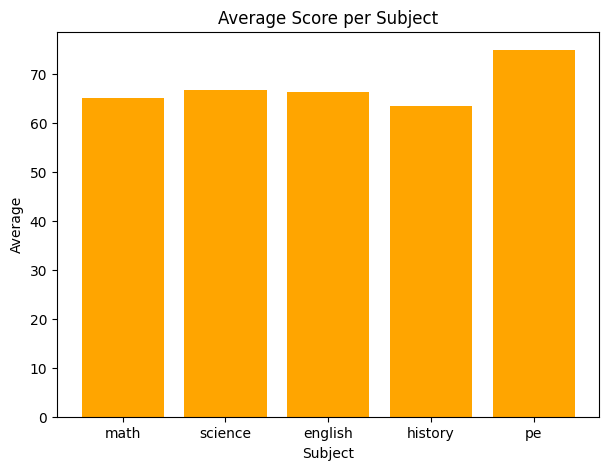

In [103]:
average_subject = df[subject_cols].mean()


plt.figure(figsize=(7,5)) #defines the size of the plot 
plt.bar(subject_cols,average_subject,color= 'orange') # defines x and y axis of the plot and can customize the color,width etc
plt.title("Average Score per Subject") # to put title we use title function and for labels we use xlabels and ylables we can also add legends to woth legend function.
plt.xlabel("Subject")
plt.ylabel("Average")

plt.savefig("plot1_bar.png")
plt.show() #it works as print for plots

### Histogram

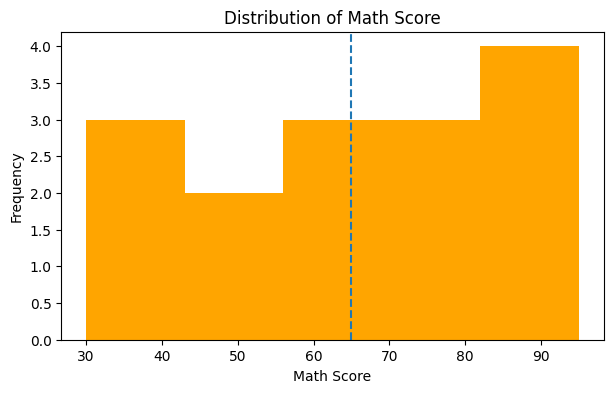

In [65]:
math_score = df['math'] # created math_score variable and copy math marks and showed on x axis.

# we have crated the bins of 5 which is showed at x axis and frequency of students is showed on y axis.
# for ex- 30-40 marks bin there are 3 students likeawise.

plt.figure(figsize = (7,4))
plt.hist(math_score, bins=5,color='orange')
mean_value = math_score.mean() # calculated the mean/average of math marks and showed it on dashed line to analyze the skweness of data.
plt.axvline(mean_value,linestyle = 'dashed')

plt.title("Distribution of Math Score")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.savefig("plot2_hit.png")
plt.show()

### Scatter Plot

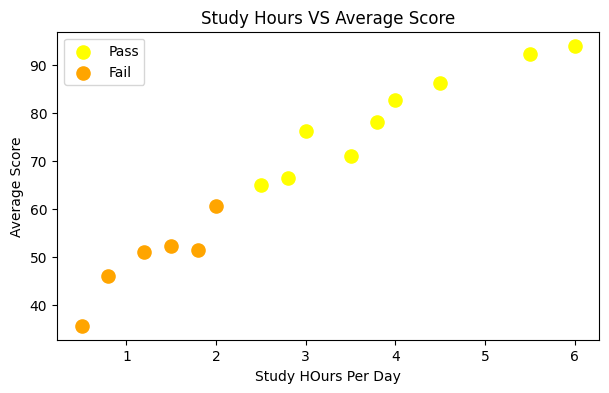

In [70]:
pass_students = df[df['passed']==1] # stored passed studens in pass_students variable
fail_students = df[df['passed']==0] # stored failed studens in fail_students variable

pass_hours = pass_students['study_hours_per_day'] # fetch the study of hours per day of passed students.
pass_avg = pass_students['avg_score'] # fetch the average marks of passed students.

fail_hours = fail_students['study_hours_per_day'] # fetch the study of hours per day of failed students.
fail_avg = fail_students['avg_score']# fetch the average  marks of failed students. 

# drew scatter plot with two possible arguemetns i.e avg marks of students who have passed in respect to their study hours per day and same for failed students.
# which shows the students who have more study hours per day have compartively more marks than who have less study hours per day.

plt.figure(figsize= (7,4))
plt.scatter(pass_hours, pass_avg, color ='yellow', label= 'Pass',s= 90)
plt.scatter(fail_hours, fail_avg, color ='orange', label = 'Fail',s=90)

plt.title("Study Hours VS Average Score")
plt.xlabel("Study HOurs Per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()



### Box Plot

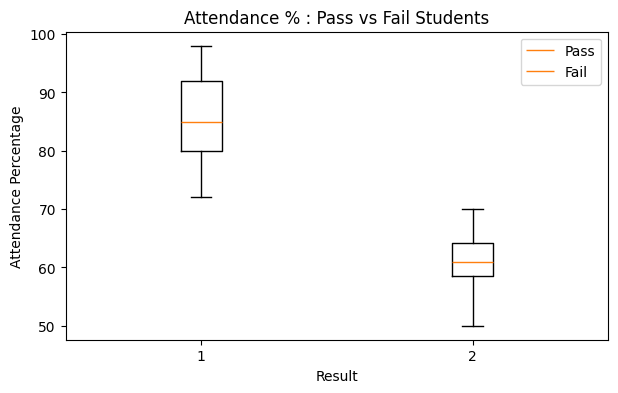

In [106]:
pass_attendance = df[df["passed"]==1]["attendance_pct"] # fetch the attendance of  passed students.
fail_attendance = df[df["passed"]==0]["attendance_pct"] # fetch the attendance of failed students.

# the first box of the plot represents tha passed students attendance have high attendance percentage  and the line inside box tells that out of 100 % passed students 75% have higher attendance than the median value.
# the second box of the plot represents tha passed students attendance have low attendance percentage  and the line inside box tells that out of 100 % failed students 75% have higher attendance than the median value.
plt.figure(figsize= (7,4))
plt.boxplot([pass_attendance, fail_attendance], label= ['Pass','Fail'])
plt.title("Attendance % : Pass vs Fail Students")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.legend()

plt.savefig("plot4_boxplot.png")
plt.show()

### Line Plot

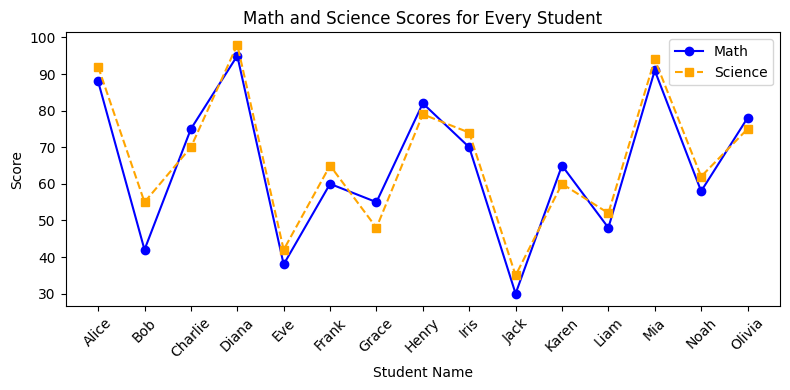

In [76]:
st_names = df['name']
math_score = df['math']
science_score = df['science']

#this is comparison of students marks between maths and science score.
# marker = "o" shows the circle at line plot and helps us analyzing the comparison among marks.

plt.figure(figsize=(8, 4))
plt.plot(st_names, math_score,    marker='o', linestyle='-',  color='blue',   label='Math')
plt.plot(st_names, science_score, marker='s', linestyle='--', color='orange', label='Science')

plt.title("Math and Science Scores for Every Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

## Task 3 — Data Visualization with Seaborn

In [77]:
import seaborn as sb # seaborn works on top of matplotlib it works along with matplolib.

### Seaborn Bar Plot

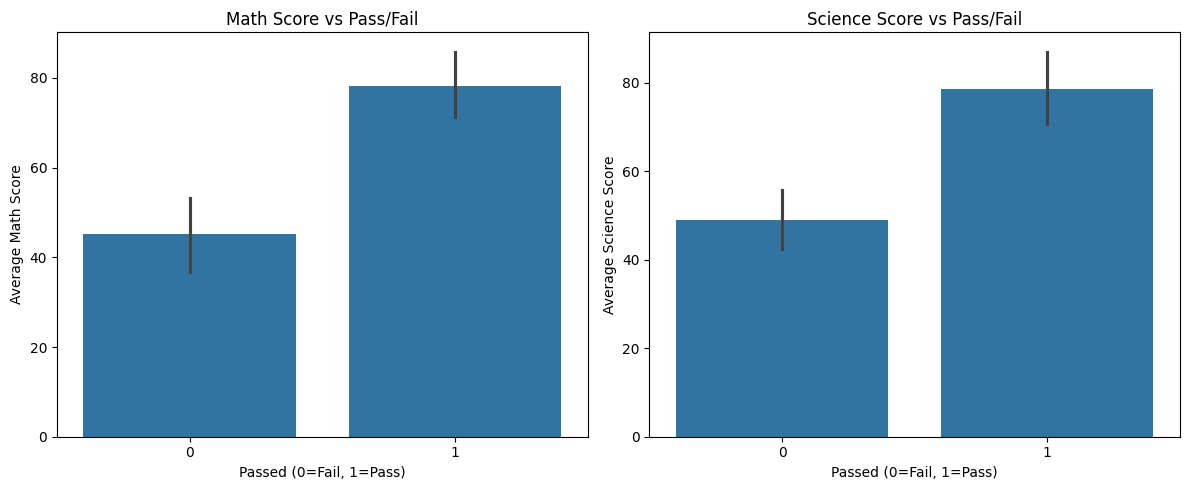

In [92]:
# the question have strictly asked us to create two bar plots side by side with the same x axis.
# which will help in analyzing the average score of different subject of both passed and failed students.

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)   # left plot ( 1 = one row, 2 = two column, 1 = first position of the sub plot).
ax2 = fig.add_subplot(1, 2, 2) # right plot ( 1 = one row, 2 = two column, 2 = second position of the sub plot).

plt.subplot(1,2,1) 
sb.barplot(data = df, x= 'passed', y = 'math',ax=ax1) # ax = ax1 tells the seaborn to plot the bar at left side
plt.title("Math Score vs Pass/Fail")
plt.xlabel("Passed (0=Fail, 1=Pass)")
plt.ylabel("Average Math Score")

plt.subplot(1,2,2)
sb.barplot(data=df, x='passed', y='science',ax=ax2) # ax = ax2 tells the seaborn to plot the bar at right side
plt.title("Science Score vs Pass/Fail")
plt.xlabel("Passed (0=Fail, 1=Pass)")
plt.ylabel("Average Science Score")

plt.tight_layout() # adjusts apacing to prevent from overlapping of sub plots.
plt.savefig("plot6_seaborn_bar.png")
plt.show()

### Seaborn Scatter Plot

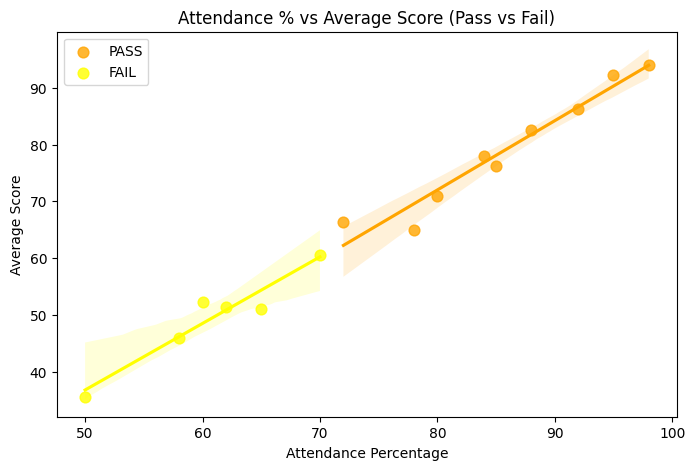

In [107]:
pass_st = df[df["passed"] ==1]
fail_st = df[df["passed"] ==0]

plt.figure(figsize =(8,5))

# with regplot we can draw a scatter plot and regresion libe both at the same time.

sb.regplot(data = pass_st, x= "attendance_pct", y = "avg_score", label ="PASS", color ="orange", scatter_kws={'s':60}) # scatter_kws defines the size of the dots
sb.regplot(data = fail_st, x= "attendance_pct", y = "avg_score", label ="FAIL", color ="yellow", scatter_kws={'s':60})

plt.title("Attendance % vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


### experience of using Seaborn vs Matplotlib

####  Matplot is much easier than seaborn as both are used in different scenario as per the requirement.
####  Like- If i want to customize more in my plots than matplot is really flexible i can easily provide colors, size, etc 
####  Whereas, seaborn is helpful in spliting the data like no need to filtering the data manually ust typed x= (basis of filtering).

## Task 4 — Machine Learning with scikit-learn 